<a href="https://colab.research.google.com/github/kundankumar09-v/weekly_assignments_CEI/blob/main/week6_kundan_kumar_vennaboina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Download MNIST Dataset

In [1]:
import kagglehub
path = kagglehub.dataset_download("awsaf49/mnist-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path to dataset files: /kaggle/input/mnist-dataset


# 2. Import PyTorch Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import os
import matplotlib.pyplot as plt

# 3. Load and Preprocess Data

In [3]:
image_data_path = os.path.join(path, 'mnist_png')

# Define transformations
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

# Load datasets
train_dataset = datasets.ImageFolder(root=os.path.join(image_data_path, 'training'), transform=transform)
test_dataset = datasets.ImageFolder(root=os.path.join(image_data_path, 'testing'), transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Function to convert DataLoader output to numpy arrays for initial noise addition
def get_all_images(data_loader):
    all_images = []
    for images, _ in data_loader:
        all_images.append(images)
    return torch.cat(all_images, dim=0).numpy()

x_train = get_all_images(train_loader)
x_test = get_all_images(test_loader)

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_test: {x_test.shape}")

Shape of x_train: (60000, 1, 28, 28)
Shape of x_test: (10000, 1, 28, 28)


# 4. Add Noise to Images

In [4]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Convert noisy numpy arrays back to PyTorch tensors and create new DataLoaders
x_train_noisy_tensor = torch.tensor(x_train_noisy, dtype=torch.float32)
x_train_clean_tensor = torch.tensor(x_train, dtype=torch.float32)
x_test_noisy_tensor = torch.tensor(x_test_noisy, dtype=torch.float32)
x_test_clean_tensor = torch.tensor(x_test, dtype=torch.float32)

train_noisy_dataset = torch.utils.data.TensorDataset(x_train_noisy_tensor, x_train_clean_tensor)
test_noisy_dataset = torch.utils.data.TensorDataset(x_test_noisy_tensor, x_test_clean_tensor)

train_noisy_loader = DataLoader(train_noisy_dataset, batch_size=32, shuffle=True)
test_noisy_loader = DataLoader(test_noisy_dataset, batch_size=32, shuffle=False)

# 5. Define Autoencoder Architecture

In [16]:
latent_dim = 32

class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = Autoencoder(latent_dim)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder.to(device)

optimizer = optim.Adam(autoencoder.parameters())
criterion = nn.BCELoss()

# 6. Train the Autoencoder Model

In [17]:
epochs = 10
train_losses = []
test_losses = []

for epoch in range(epochs):
    running_loss = 0.0
    for noisy_imgs, clean_imgs in train_noisy_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        optimizer.zero_grad()
        outputs = autoencoder(noisy_imgs)
        loss = criterion(outputs, clean_imgs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_noisy_loader)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_train_loss}")

    test_loss = 0.0
    with torch.no_grad():
        for noisy_imgs, clean_imgs in test_noisy_loader:
            noisy_imgs = noisy_imgs.to(device)
            clean_imgs = clean_imgs.to(device)
            outputs = autoencoder(noisy_imgs)
            loss = criterion(outputs, clean_imgs)
            test_loss += loss.item()
    avg_test_loss = test_loss / len(test_noisy_loader)
    test_losses.append(avg_test_loss)
    print(f"Test Loss: {avg_test_loss}")

Epoch 1, Loss: 0.13578276744683584
Test Loss: 0.10574280910979444
Epoch 2, Loss: 0.10372595825592677
Test Loss: 0.10161290320154197
Epoch 3, Loss: 0.10046370961268743
Test Loss: 0.09927549946327179
Epoch 4, Loss: 0.0987294577439626
Test Loss: 0.09836976139690168
Epoch 5, Loss: 0.09758258721828461
Test Loss: 0.09819493884333787
Epoch 6, Loss: 0.09668330394029617
Test Loss: 0.0976144418763086
Epoch 7, Loss: 0.09600700454711913
Test Loss: 0.0974088581725241
Epoch 8, Loss: 0.0955095090786616
Test Loss: 0.09691358524294326
Epoch 9, Loss: 0.09503514082034428
Test Loss: 0.09690289623059403
Epoch 10, Loss: 0.09465886240800221
Test Loss: 0.09665902192219378


# 7. Plot Training and Validation Loss (Content Moved)

In [20]:
# This cell's content for plotting training and test loss has been moved to the 'Final Evaluation' section at the end of the notebook.

# 8. Evaluate Denoising Performance (Content Moved)

In [21]:
# This cell's content for evaluating denoising performance has been moved to the 'Final Evaluation' section at the end of the notebook.

# 9. Visualize Denoised Images

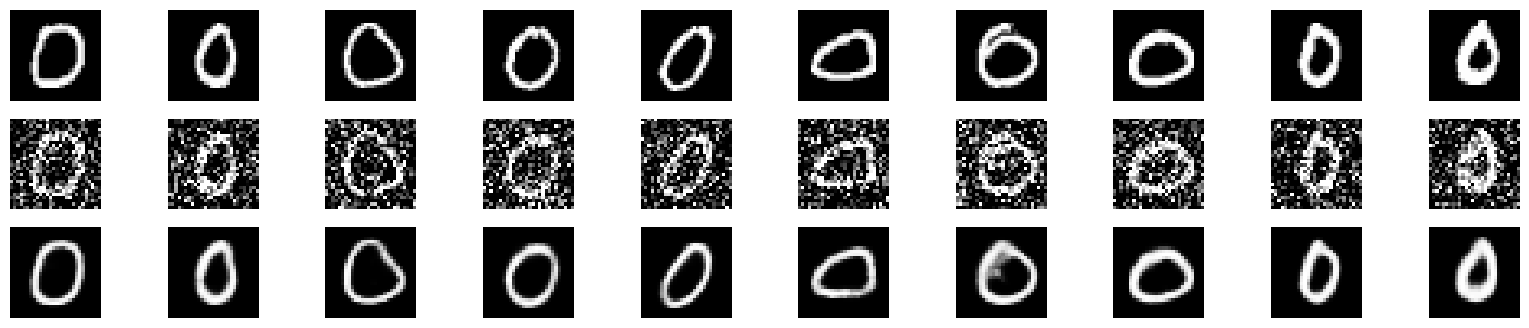

In [8]:
n = 10
plt.figure(figsize=(20, 4))

with torch.no_grad():
    for noisy_imgs, clean_imgs in test_noisy_loader:
        noisy_imgs = noisy_imgs.to(device)
        # Removed the incorrect permute operation
        outputs = autoencoder(noisy_imgs).cpu()
        clean_imgs = clean_imgs.cpu()
        noisy_imgs = noisy_imgs.cpu()
        break

for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(clean_imgs[i].squeeze().numpy(), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(noisy_imgs[i].squeeze().numpy(), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(3, n, i + 1 + n * 2)
    plt.imshow(outputs[i].squeeze().numpy(), cmap='gray')
    ax.axis('off')
plt.show()

# 10. TensorFlow Imports (Previous Attempt)

In [9]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt

# 11. TensorFlow Data Loading (Previous Attempt)

In [10]:
image_data_path = os.path.join(path, 'mnist_png')

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(image_data_path, 'training'),
    labels=None,
    color_mode='grayscale',
    image_size=(28, 28),
    interpolation='bilinear',
    batch_size=32,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(image_data_path, 'testing'),
    labels=None,
    color_mode='grayscale',
    image_size=(28, 28),
    interpolation='bilinear',
    batch_size=32,
    shuffle=False
)

def normalize_img(image, label=None):
  image = tf.cast(image, tf.float32) / 255.0
  return image

train_ds = train_ds.map(normalize_img)
test_ds = test_ds.map(normalize_img)

x_train = np.concatenate(list(train_ds.as_numpy_iterator()))
x_test = np.concatenate(list(test_ds.as_numpy_iterator()))

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_test: {x_test.shape}")

Found 60000 files.
Found 10000 files.
Shape of x_train: (60000, 28, 28, 1)
Shape of x_test: (10000, 28, 28, 1)


# 12. TensorFlow Noise Addition (Previous Attempt)

In [11]:
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# 13. TensorFlow Autoencoder Definition (Previous Attempt)

In [12]:
latent_dim = 32

class Autoencoder(tf.keras.Model):
  def __init__(self, latent_dim):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim
    self.encoder = tf.keras.Sequential([
      tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),
      tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2),
      tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=2),
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(latent_dim)
    ])
    self.decoder = tf.keras.Sequential([
      tf.keras.layers.Dense(7*7*64, activation='relu'),
      tf.keras.layers.Reshape((7, 7, 64)),
      tf.keras.layers.Conv2DTranspose(64, kernel_size=3, strides=2, activation='relu', padding='same'),
      tf.keras.layers.Conv2DTranspose(32, kernel_size=3, strides=2, activation='relu', padding='same'),
      tf.keras.layers.Conv2D(1, kernel_size=3, activation='sigmoid', padding='same')
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = Autoencoder(latent_dim)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


# 14. TensorFlow Model Training (Previous Attempt)

In [13]:
autoencoder.fit(x_train_noisy, x_train, epochs=10, shuffle=True, validation_data=(x_test_noisy, x_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 124s 65ms/step - loss: 0.1458 - val_loss: 0.1029
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - loss: 0.1010 - val_loss: 0.0985
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 119s 63ms/step - loss: 0.0977 - val_loss: 0.0970
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 63ms/step - loss: 0.0960 - val_loss: 0.0966
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 141s 63ms/step - loss: 0.0949 - val_loss: 0.0959
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 63ms/step - loss: 0.0941 - val_loss: 0.0957
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 120s 64ms/step - loss: 0.0934 - val_loss: 0.0955
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 119s 64ms/step - loss: 0.0929 - val_loss: 0.0956
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 118s 63ms/step - loss: 0.0924 - val_loss: 0.0951
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 119s 63ms/step - loss: 0.0920 - val_loss: 0.0953


# 15. TensorFlow Visualization (Previous Attempt)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


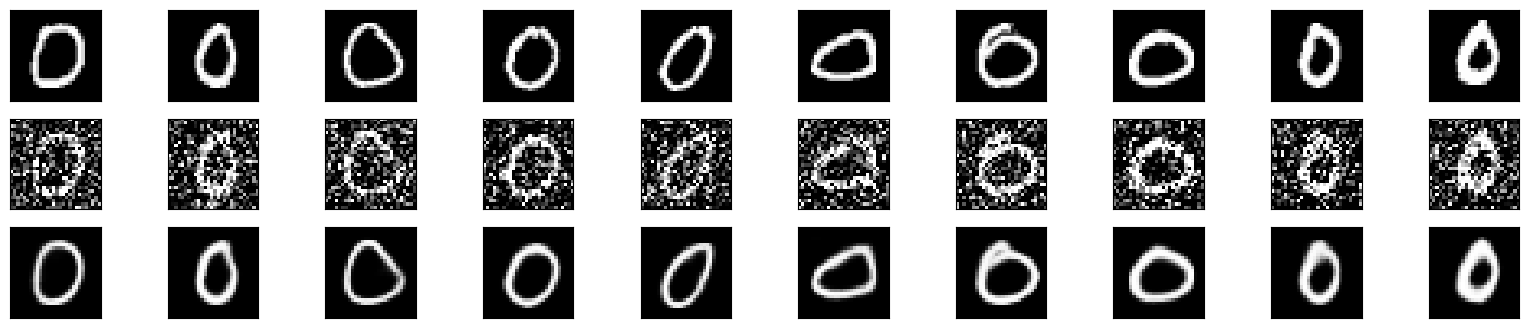

In [14]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3, n, i + 1 + n * 2)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# 17. Final Evaluation

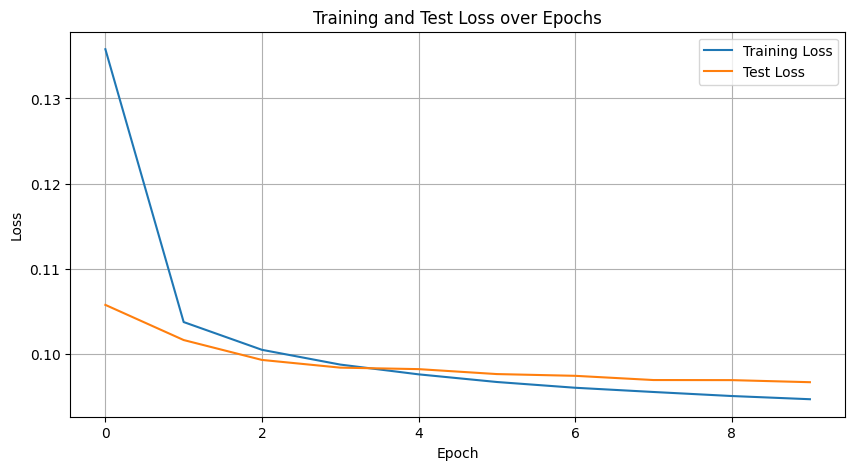

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Training and Test Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

autoencoder.eval() # Set model to evaluation mode

# Collect all clean and denoised images from the test set
all_clean_images = []
all_denoised_images = []

with torch.no_grad():
    for noisy_imgs, clean_imgs in test_noisy_loader:
        noisy_imgs = noisy_imgs.to(device)
        outputs = autoencoder(noisy_imgs).cpu()
        all_clean_images.append(clean_imgs.numpy())
        all_denoised_images.append(outputs.numpy())

clean_images_np = np.concatenate(all_clean_images, axis=0)
denoised_images_np = np.concatenate(all_denoised_images, axis=0)

# Reshape images to (batch, height, width) for metrics calculation
clean_images_np = clean_images_np.squeeze(axis=1)
denoised_images_np = denoised_images_np.squeeze(axis=1)

mse_values = []
psnr_values = []
ssim_values = []

for i in range(len(clean_images_np)):
    clean_img = clean_images_np[i]
    denoised_img = denoised_images_np[i]

    # MSE
    mse = np.mean((clean_img - denoised_img)**2)
    mse_values.append(mse)

    # PSNR
    # Data range is 0-1 for normalized images
    psnr = peak_signal_noise_ratio(clean_img, denoised_img, data_range=1.0)
    psnr_values.append(psnr)

    # SSIM
    # Assumes data_range=1.0 by default for images with float dtype
    ssim = structural_similarity(clean_img, denoised_img, data_range=1.0)
    ssim_values.append(ssim)

print(f"Mean Squared Error (MSE): {np.mean(mse_values):.4f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {np.mean(psnr_values):.4f} dB")
print(f"Structural Similarity Index (SSIM): {np.mean(ssim_values):.4f}")

Mean Squared Error (MSE): 0.0113
Peak Signal-to-Noise Ratio (PSNR): 19.8816 dB
Structural Similarity Index (SSIM): 0.8661
